In [5]:
# Importar librerías necesarias

# Librerías estándar de Python
import json

# Librerías de terceros
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset


# ==============================
# CONFIGURACIÓN DE DISPOSITIVO
# ==============================

# Selecciona GPU si está disponible, de lo contrario usa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Muestra el dispositivo que se está utilizando
print(f"Usando: {device}")

Usando: cpu


In [6]:
#Cargar datos y definir target

df = pd.read_csv("data_loan_clean.csv", low_memory=False)
cols = json.load(open("esquema_modelo.json"))["columnas_modelo"]
cols = [c for c in cols if c not in ["loan_status", "default", "verification_status_joint"]]

status_map = {
    "Fully Paid":                                          0,
    "Does not meet the credit policy. Status:Fully Paid":  0,
    "Charged Off":                                         1,
    "Default":                                             1,
    "Late (31-120 days)":                                  1,
    "Does not meet the credit policy. Status:Charged Off": 1,
}

df = df[df["loan_status"].isin(status_map)].copy()
df["default"] = df["loan_status"].map(status_map)

print(f"Filas para modelo: {len(df):,}")
print(df["default"].value_counts(normalize=True).mul(100).round(2))

Filas para modelo: 268,530
default
0    78.1
1    21.9
Name: proportion, dtype: float64


In [7]:
# Split y escalado

X = df[cols].values
y = df["default"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Default en train: {y_train.mean()*100:.2f}%")

Train: (214824, 66) | Test: (53706, 66)
Default en train: 21.90%


In [8]:

# Convertir a tensores y crear DataLoaders

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False)

print(f"Batches en train: {len(train_loader)}")

Batches en train: 420


In [9]:
# Definir arquitectura de la red neuronal
# Estructura: Input → 128 → 64 → 32 → 1
# Dropout para regularización, BatchNorm para estabilidad

class CreditRiskNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            # Capa 1
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Capa 2
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Capa 3
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Salida — probabilidad de default
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

model = CreditRiskNN(input_dim=len(cols)).to(device)
print(model)
print(f"\nParámetros totales: {sum(p.numel() for p in model.parameters()):,}")

CreditRiskNN(
  (network): Sequential(
    (0): Linear(in_features=66, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
    (13): Sigmoid()
  )
)

Parámetros totales: 19,393


In [10]:
# Configurar entrenamiento
# BCELoss con pos_weight para manejar desbalance de clases

# Peso para clase positiva (default) según desbalance
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
print(f"pos_weight: {pos_weight.item():.2f}  (negativos/positivos)")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5
)

pos_weight: 3.57  (negativos/positivos)


In [11]:

# Loop de entrenamiento

EPOCHS = 30
history = {"train_loss": [], "val_auc": []}

for epoch in range(1, EPOCHS + 1):
    # ── Entrenamiento ──────────────────────────────────────────
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # ── Validación ─────────────────────────────────────────────
    model.eval()
    with torch.no_grad():
        y_prob_val = model(X_test_t).cpu().numpy()

    val_auc = roc_auc_score(y_test, y_prob_val)
    scheduler.step(val_auc)
    print(f"Epoch {epoch} | LR: {optimizer.param_groups[0]['lr']}")

    history["train_loss"].append(avg_loss)
    history["val_auc"].append(val_auc)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | AUC: {val_auc:.4f}")

Epoch 1 | LR: 0.001
Epoch 01/30 | Loss: 1.0569 | AUC: 0.6894
Epoch 2 | LR: 0.001
Epoch 3 | LR: 0.001
Epoch 4 | LR: 0.001
Epoch 5 | LR: 0.001
Epoch 05/30 | Loss: 1.0366 | AUC: 0.6952
Epoch 6 | LR: 0.001
Epoch 7 | LR: 0.001
Epoch 8 | LR: 0.001
Epoch 9 | LR: 0.001
Epoch 10 | LR: 0.001
Epoch 10/30 | Loss: 1.0345 | AUC: 0.6965
Epoch 11 | LR: 0.001
Epoch 12 | LR: 0.001
Epoch 13 | LR: 0.001
Epoch 14 | LR: 0.001
Epoch 15 | LR: 0.001
Epoch 15/30 | Loss: 1.0334 | AUC: 0.6978
Epoch 16 | LR: 0.0005
Epoch 17 | LR: 0.0005
Epoch 18 | LR: 0.0005
Epoch 19 | LR: 0.0005
Epoch 20 | LR: 0.0005
Epoch 20/30 | Loss: 1.0310 | AUC: 0.6936
Epoch 21 | LR: 0.0005
Epoch 22 | LR: 0.0005
Epoch 23 | LR: 0.0005
Epoch 24 | LR: 0.0005
Epoch 25 | LR: 0.0005
Epoch 25/30 | Loss: 1.0304 | AUC: 0.6986
Epoch 26 | LR: 0.0005
Epoch 27 | LR: 0.00025
Epoch 28 | LR: 0.00025
Epoch 29 | LR: 0.00025
Epoch 30 | LR: 0.00025
Epoch 30/30 | Loss: 1.0283 | AUC: 0.6998


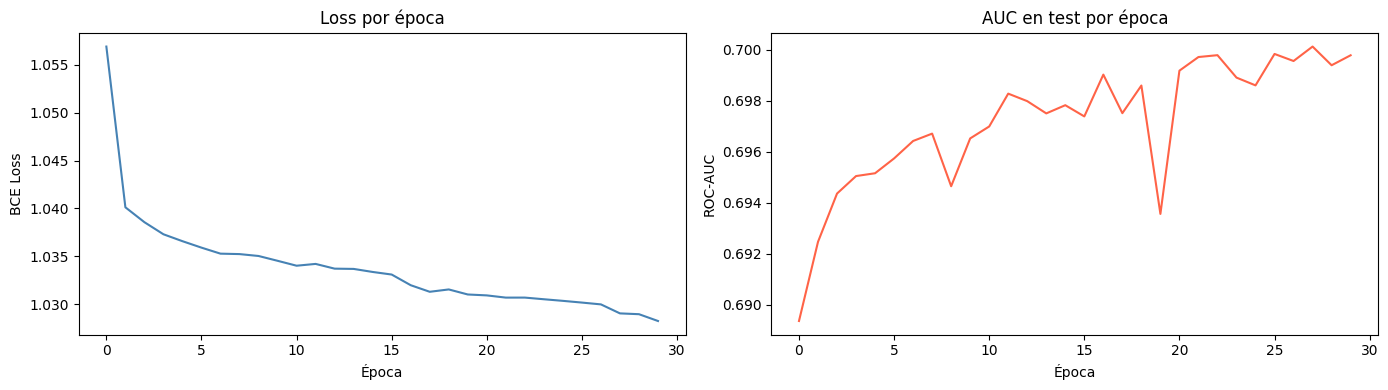

In [12]:

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history["train_loss"], color="steelblue")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("BCE Loss")

axes[1].plot(history["val_auc"], color="tomato")
axes[1].set_title("AUC en test por época")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("ROC-AUC")

plt.tight_layout()
plt.show()

In [13]:
# ─────────────────────────────────────────────────────────────────
# CELDA 9 — Métricas finales
# ─────────────────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    y_prob = model(X_test_t).cpu().numpy()

y_pred = (y_prob >= 0.5).astype(int)

print("── Classification Report ──────────────────────────────────")
print(classification_report(y_test, y_pred,
                             target_names=["No Default", "Default"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

── Classification Report ──────────────────────────────────
              precision    recall  f1-score   support

  No Default       0.83      0.83      0.83     41942
     Default       0.40      0.42      0.41     11764

    accuracy                           0.74     53706
   macro avg       0.62      0.62      0.62     53706
weighted avg       0.74      0.74      0.74     53706

ROC-AUC: 0.6998


In [14]:
# ─────────────────────────────────────────────────────────────────
# CELDA 10 — Guardar modelo y scaler para la app web
# ─────────────────────────────────────────────────────────────────
import pickle

torch.save(model.state_dict(), "credit_risk_nn.pth")
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("✅ Modelo guardado en credit_risk_nn.pth")
print("✅ Scaler guardado en scaler.pkl")

✅ Modelo guardado en credit_risk_nn.pth
✅ Scaler guardado en scaler.pkl
